In [1]:
# Install required library
!pip install lifetimes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 7.7 MB/s eta 0:00:00


In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from lifetimes import BetaGeoFitter
from lifetimes import GammaGammaFitter

In [3]:
# Load Dataset (Public Dataset)

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
df = pd.read_excel(url)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# Data Cleaning

# Remove missing customer IDs
df = df.dropna(subset=['CustomerID'])

# Remove negative or zero quantity
df = df[df['Quantity'] > 0]

# Create Total Price column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Convert date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [5]:
# RFM Feature Engineering

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Add customer "age"
rfm['T'] = rfm['Recency'] + rfm['Frequency']

rfm.head()


,Recency,Frequency,Monetary,T
CustomerID,,,,
12346.0,326,1,77183.60,327
12347.0,2,7,4310.00,9
12348.0,75,4,1797.24,79
12349.0,19,1,1757.55,20
12350.0,310,1,334.40,311


In [6]:
# Train BG/NBD Model

bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(rfm['Frequency'], rfm['Recency'], rfm['T'])

# Predict future purchases (next 30 days)
rfm['Predicted_Purchases'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    30,
    rfm['Frequency'],
    rfm['Recency'],
    rfm['T']
)

In [8]:
# Filter valid customers for Gamma-Gamma
# Keep only customers with:
# Frequency > 0 and Monetary > 0
rfm_filtered = rfm[(rfm['Frequency'] > 0) & (rfm['Monetary'] > 0)]

print("Filtered dataset shape:", rfm_filtered.shape)

Filtered dataset shape: (4338, 5)


In [10]:
# Train Gamma-Gamma Model (CLV)

ggf = GammaGammaFitter(penalizer_coef=0.001)
ggf.fit(rfm_filtered['Frequency'], rfm_filtered['Monetary'])

# Calculate CLV
rfm_filtered['CLV'] = ggf.customer_lifetime_value(
    bgf,
    rfm_filtered['Frequency'],
    rfm_filtered['Recency'],
    rfm_filtered['T'],
    rfm_filtered['Monetary'],
    time=6,
    freq="D",
    discount_rate=0.01
)

In [12]:
# Results

# Top customers
top_customers = rfm_filtered.sort_values(by='CLV', ascending=False).head(10)

print("\nTop 10 High-Value Customers:")
print(top_customers[['CLV', 'Predicted_Purchases']])


Top 10 High-Value Customers:
                     CLV  Predicted_Purchases
CustomerID                                   
16446.0     5.778364e+06             9.318674
12753.0     4.714541e+05             4.933020
16000.0     3.826061e+05             8.055865
12678.0     3.389982e+05             4.105862
12744.0     3.260703e+05             3.171632
12477.0     2.908535e+05             4.933020
12557.0     2.847549e+05             5.495358
12451.0     2.379551e+05             6.313034
17340.0     2.241403e+05             3.998109
18139.0     2.028459e+05             5.523764


In [13]:
#Summary Statistics
print("\nCLV Summary:")
print(rfm_filtered['CLV'].describe())


CLV Summary:
count    4.338000e+03
mean     1.335310e+04
std      9.102287e+04
min      0.000000e+00
25%      4.470277e+02
50%      2.526851e+03
75%      1.331414e+04
max      5.778364e+06
Name: CLV, dtype: float64


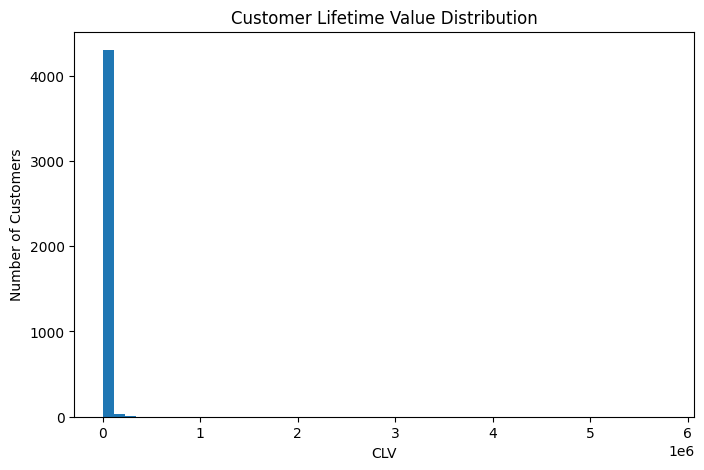

In [18]:
# Visualization

plt.figure(figsize=(8,5))
plt.hist(rfm_filtered['CLV'], bins=50)
plt.title("Customer Lifetime Value Distribution")
plt.xlabel("CLV")
plt.ylabel("Number of Customers")
plt.show()


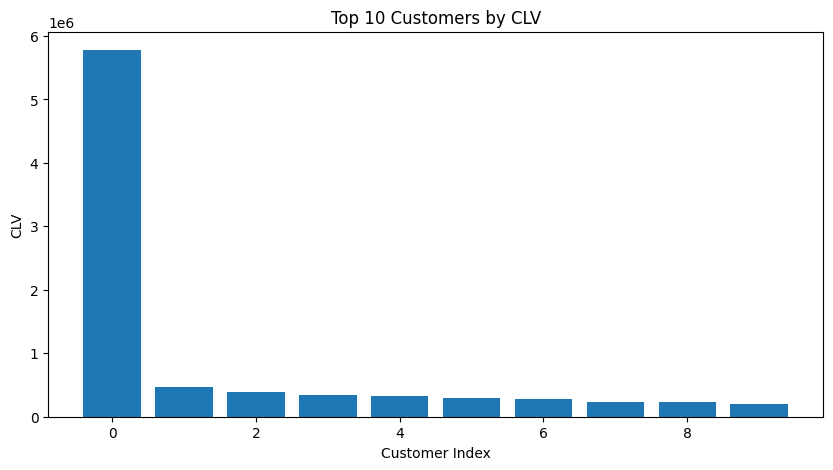

In [19]:
top_10 = rfm_filtered.sort_values(by='CLV', ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(range(len(top_10)), top_10['CLV'])
plt.title("Top 10 Customers by CLV")
plt.xlabel("Customer Index")
plt.ylabel("CLV")
plt.show()

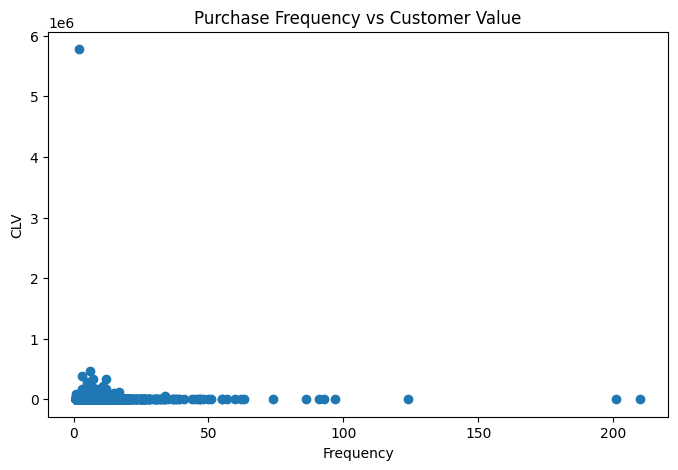

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(rfm_filtered['Frequency'], rfm_filtered['CLV'])
plt.title("Purchase Frequency vs Customer Value")
plt.xlabel("Frequency")
plt.ylabel("CLV")
plt.show()

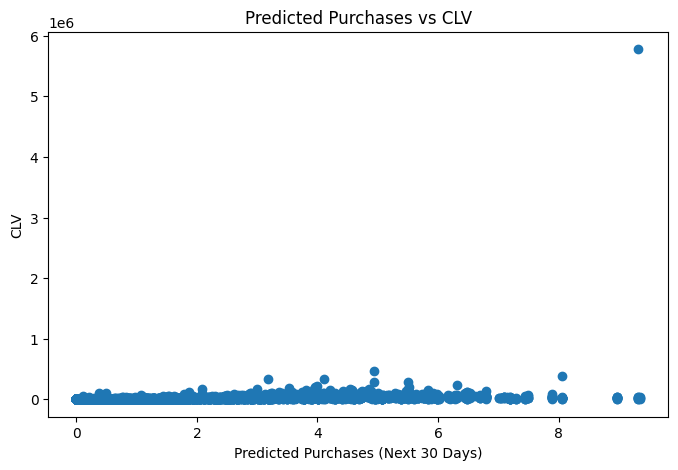

In [21]:
plt.figure(figsize=(8,5))
plt.scatter(rfm_filtered['Predicted_Purchases'], rfm_filtered['CLV'])
plt.title("Predicted Purchases vs CLV")
plt.xlabel("Predicted Purchases (Next 30 Days)")
plt.ylabel("CLV")
plt.show()

In [22]:
rfm_filtered.to_csv("final_clv_predictions.csv")
print("Saved: final_clv_predictions.csv")

Saved: final_clv_predictions.csv


In [23]:
# Create segments
rfm_filtered['Segment'] = pd.qcut(rfm_filtered['CLV'], q=3, labels=['Low', 'Medium', 'High'])

# Count customers per segment
segment_counts = rfm_filtered['Segment'].value_counts()

print("\nCustomer Segments:")
print(segment_counts)


Customer Segments:
Segment
Low       1446
Medium    1446
High      1446
Name: count, dtype: int64


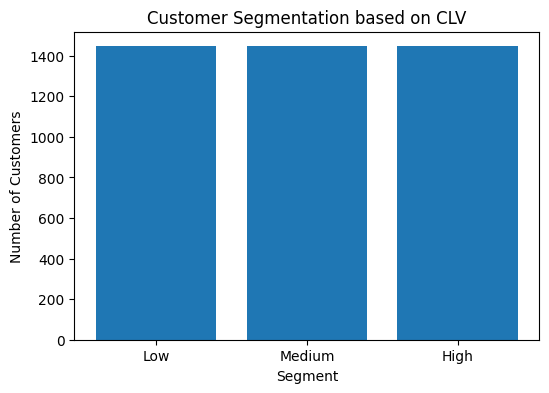

In [24]:
plt.figure(figsize=(6,4))
plt.bar(segment_counts.index, segment_counts.values)
plt.title("Customer Segmentation based on CLV")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()